In [103]:
# In this step, we import the libraries that we will use
# for data analysis, preprocessing, and visualization.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
# The UAV attack dataset is stored as a CSV file on Google Drive.
# We mount Google Drive to the Colab environment and read the dataset.from google.colab import drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv(
    "/content/drive/My Drive/Colab Notebooks/data mining for cybersecurity - data/UAV_Attack_Dataset_SUBSET.csv"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


PREPROCESSING

In [105]:
# In this step, we explore the general structure of the dataset
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6046 entries, 0 to 6045
Data columns (total 59 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           6046 non-null   int64  
 1   control[0]          6046 non-null   float64
 2   control[1]          6046 non-null   float64
 3   control[2]          6046 non-null   float64
 4   control[3]          6046 non-null   float64
 5   control[4]          6046 non-null   float64
 6   control[5]          6046 non-null   float64
 7   control[6]          6046 non-null   float64
 8   control[7]          6046 non-null   float64
 9   lat                 6046 non-null   int64  
 10  lon                 6046 non-null   int64  
 11  alt                 6046 non-null   int64  
 12  alt_ellipsoid       6046 non-null   int64  
 13  eph                 6046 non-null   float64
 14  epv                 6046 non-null   float64
 15  hdop                6046 non-null   float64
 16  vdop  

In [106]:
# We use descriptive statistics to understand the distribution and range of numerical features.
df.shape
df.columns
df.describe()

,timestamp,control[0],control[1],control[2],control[3],control[4],control[5],control[6],control[7],lat,...,x_loc,y_loc,z_loc,vx_loc,vy_loc,vz_loc,eph_loc,epv_loc,evh_loc,heading_loc
count,6.046000e+03,6046.000000,6046.000000,6046.000000,6046.000000,6046.0,6046.0,6046.0,6046.0,6.046000e+03,...,6046.000000,6046.000000,6046.000000,6046.000000,6046.000000,6046.000000,6046.000000,6046.000000,6046.000000,6046.000000
mean,5.376898e+08,0.084152,0.066922,-0.080200,0.257165,0.0,0.0,0.0,-1.0,3.620482e+08,...,1.751808,0.360216,-1.556087,0.004795,0.029849,0.005390,0.624154,0.416505,0.186230,-2.396451
std,1.831201e+08,0.102396,0.082700,0.083084,0.056247,0.0,0.0,0.0,0.0,1.916545e+02,...,2.357706,0.772128,1.752791,0.286941,0.235006,0.151707,0.301895,0.036477,0.064943,0.177780
min,2.588503e+08,-1.485157,-0.876393,-1.644868,0.001000,0.0,0.0,0.0,-1.0,3.620479e+08,...,-0.871747,-1.943737,-4.314290,-1.339532,-2.485200,-1.202134,0.344130,0.366192,0.135556,-3.005950
25%,3.717637e+08,0.037054,0.058863,-0.082428,0.256797,0.0,0.0,0.0,-1.0,3.620481e+08,...,0.362710,0.101015,-3.476729,-0.074597,-0.030650,-0.061030,0.469101,0.392377,0.146312,-2.495622
50%,4.994483e+08,0.085359,0.074219,-0.076194,0.269763,0.0,0.0,0.0,-1.0,3.620482e+08,...,1.559593,0.276120,-0.339672,-0.020638,0.010312,0.008221,0.530888,0.404824,0.156492,-2.378432
75%,7.103332e+08,0.135983,0.088388,-0.071127,0.279082,0.0,0.0,0.0,-1.0,3.620482e+08,...,2.379652,0.533321,-0.139221,0.035395,0.085577,0.095668,0.602056,0.431040,0.195255,-2.324453
max,8.614571e+08,1.672828,0.738873,0.515779,0.431112,0.0,0.0,0.0,-1.0,3.620494e+08,...,16.380102,5.114530,0.752707,2.626024,1.430061,0.765091,1.783711,0.570500,0.451137,0.435306


In [107]:
# Here, we check whether the dataset contains missing values.
missing_values = df.isnull().sum()
missing_values

,0
timestamp,0
control[0],0
control[1],0
control[2],0
control[3],0
control[4],0
control[5],0
control[6],0
control[7],0
lat,0


class
benign flight    2463
gps jamming      2218
gps spoofing     1365
Name: count, dtype: int64
Total missing values: 0


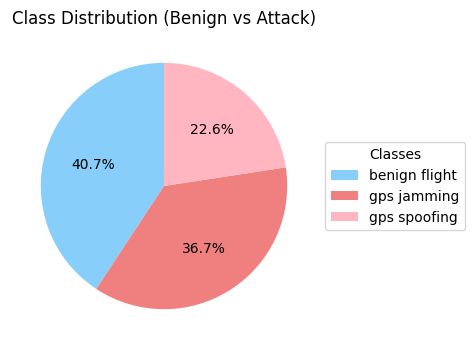

In [108]:
# # In this step, we analyze the label column to understand how many benign and attack samples exist in the dataset.
# This helps us identify whether the dataset is balanced or imbalanced.
print(df['class'].value_counts())
print("Total missing values:", df.isna().sum().sum())

# Class distribution
class_counts = df['class'].value_counts()

labels = class_counts.index
sizes = class_counts.values
colors = ['lightskyblue', 'lightcoral', 'lightpink']  # Benign / Attack

plt.figure(figsize=(4, 4))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Class Distribution (Benign vs Attack)')

plt.legend(
    wedges,
    labels,
    title="Classes",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.show()

In [109]:
# We also calculate the percentage distribution of each class.
# This helps us determine whether the dataset is balanced or imbalanced.

df['class'].value_counts(normalize=True) * 100

,proportion
class,
benign flight,40.737678
gps jamming,36.685412
gps spoofing,22.576910


In [110]:
# In this step, we check whether the dataset contains duplicate rows.
# Duplicate samples can bias the learning process of a model.

duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [111]:
# Here, we inspect the data types of each feature.
# This allows us to confirm that all features are numerical and suitable for model training.

df.dtypes

,0
timestamp,int64
control[0],float64
control[1],float64
control[2],float64
control[3],float64
control[4],float64
control[5],float64
control[6],float64
control[7],float64
lat,int64


In [112]:
# We explicitly check for categorical features
categorical_columns = df.select_dtypes(include='object').columns
categorical_columns

Index(['class'], dtype='object')

VISUALIZATION

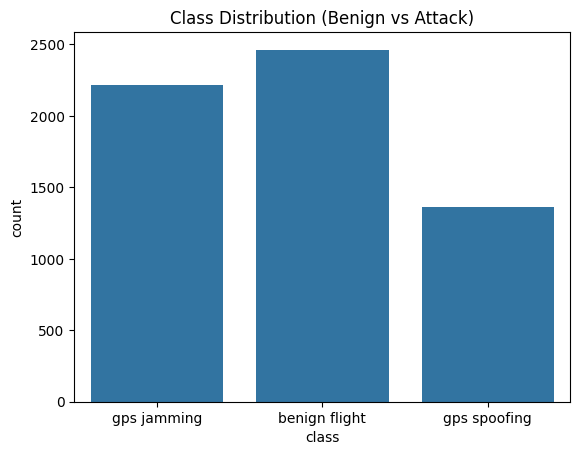

In [113]:
# We visualize the distribution of benign and attack samples.

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='class', data=df)
plt.title("Class Distribution (Benign vs Attack)")
plt.show()

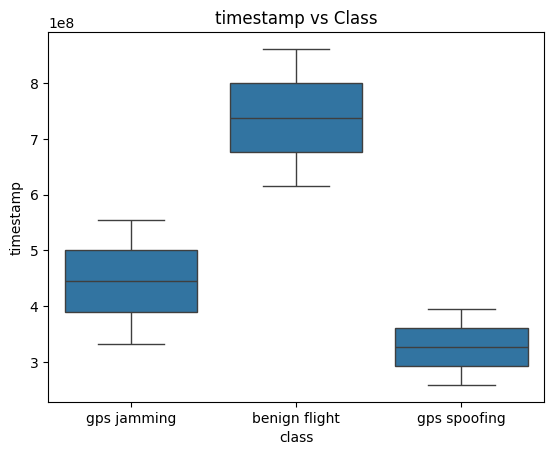

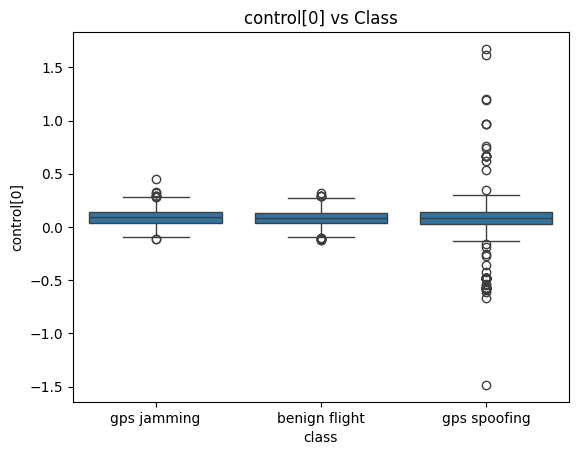

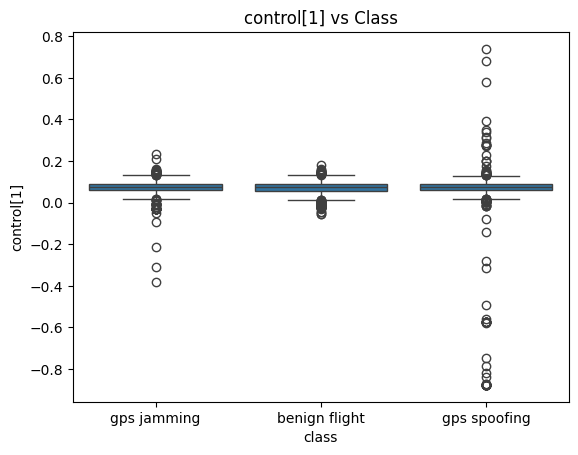

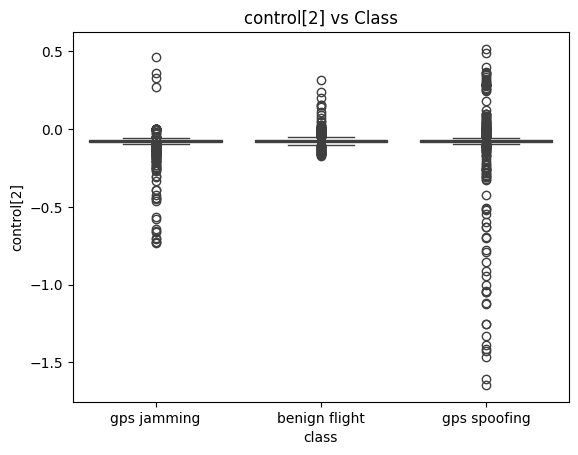

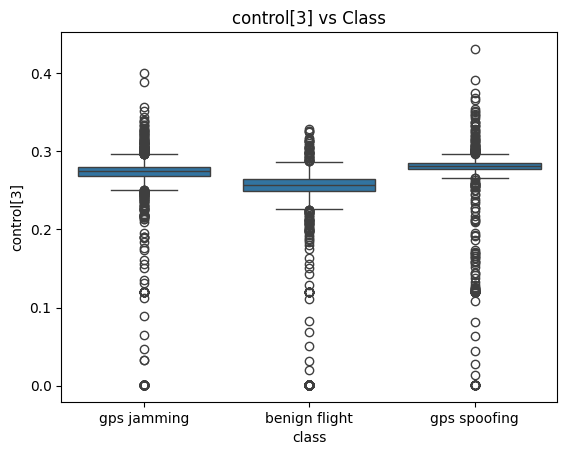

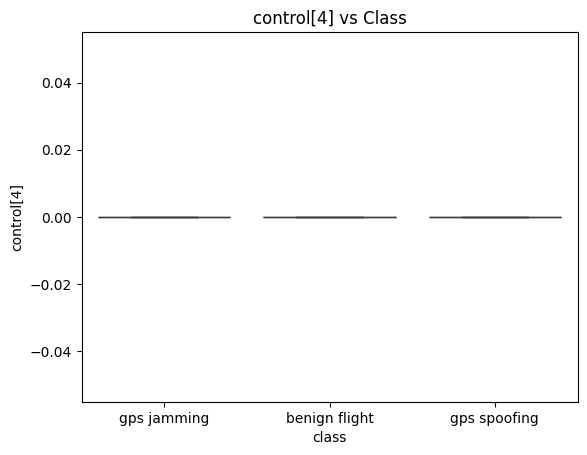

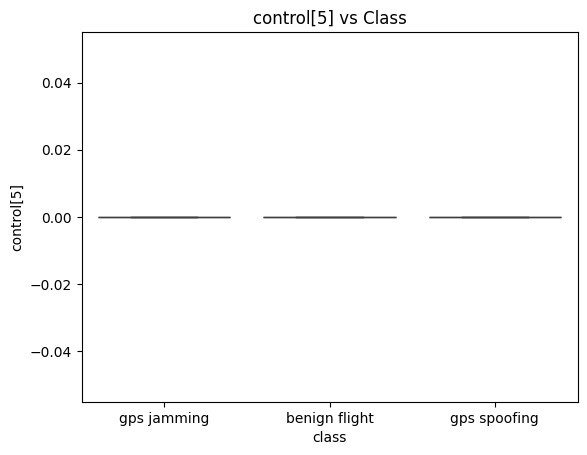

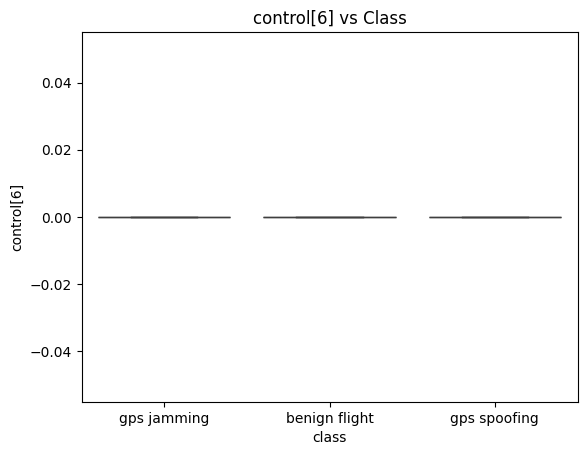

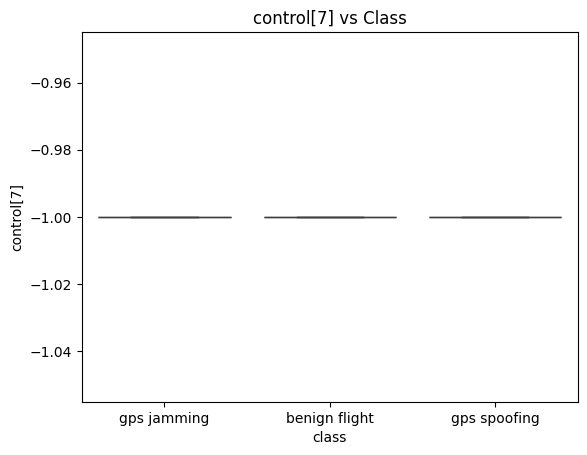

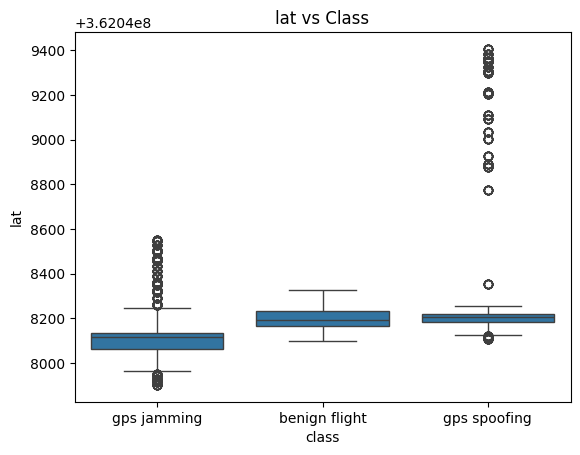

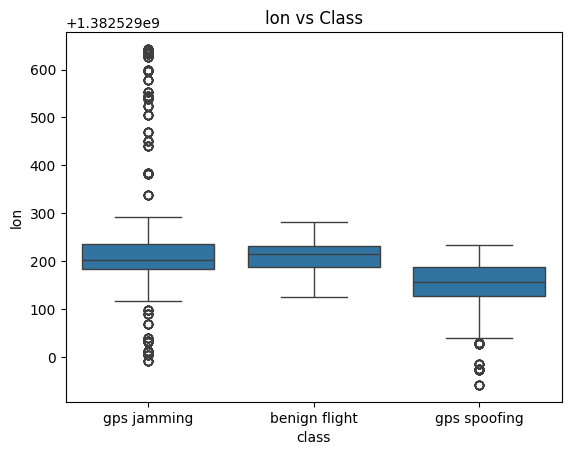

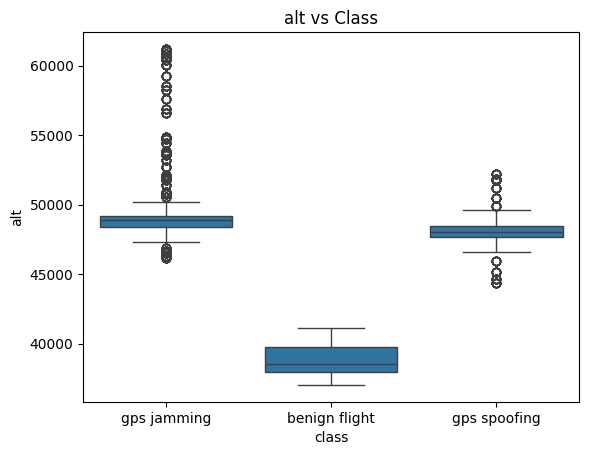

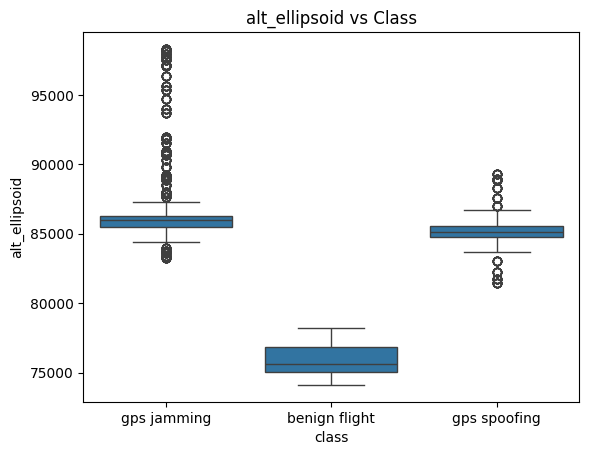

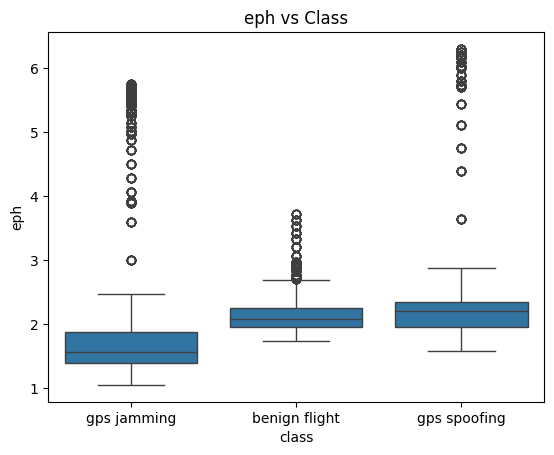

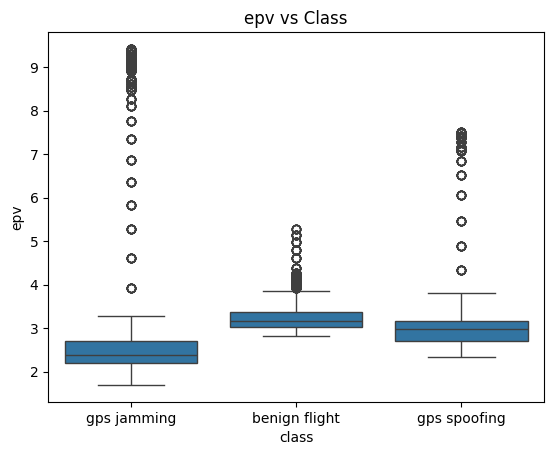

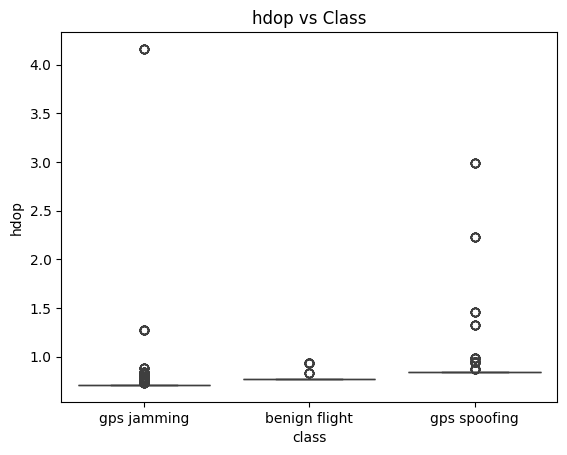

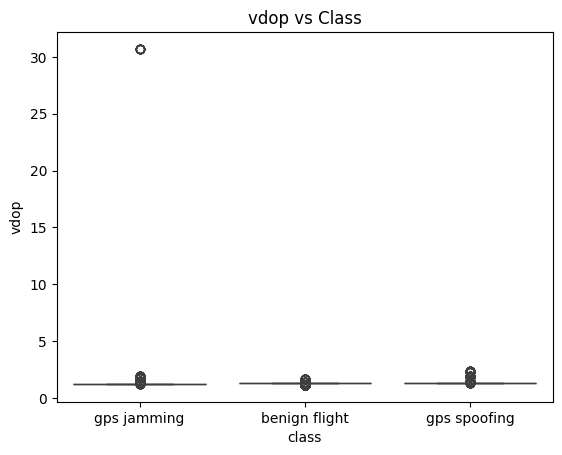

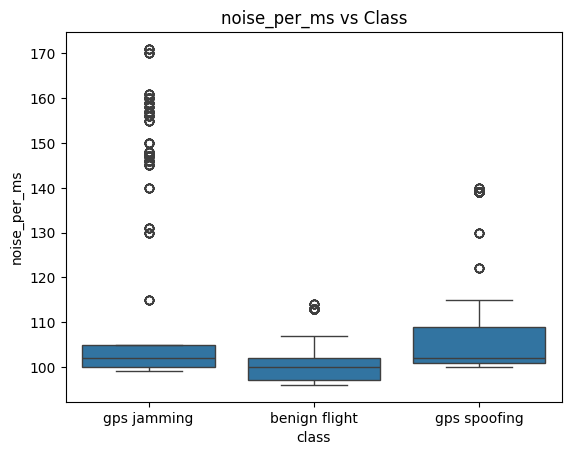

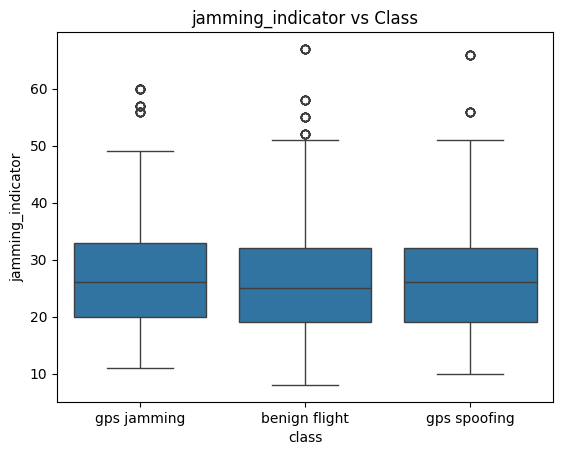

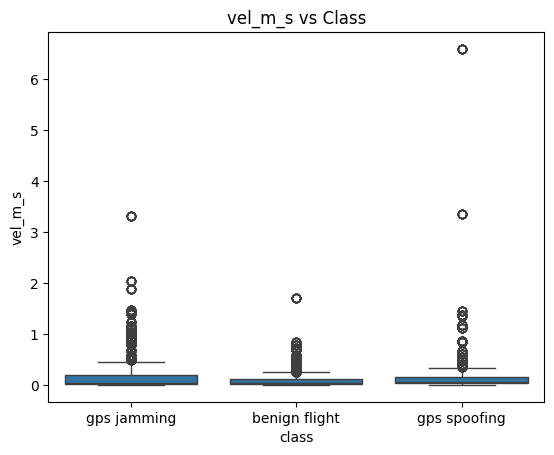

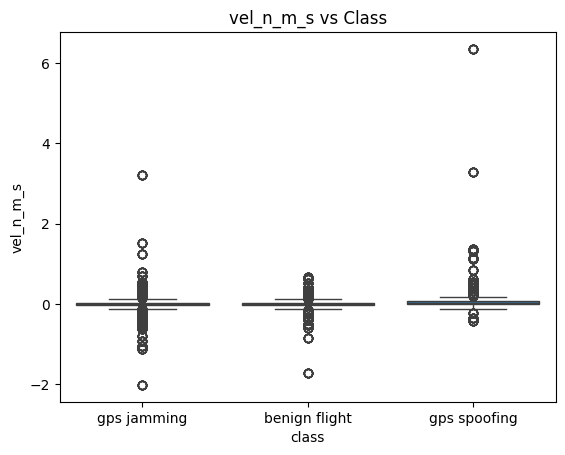

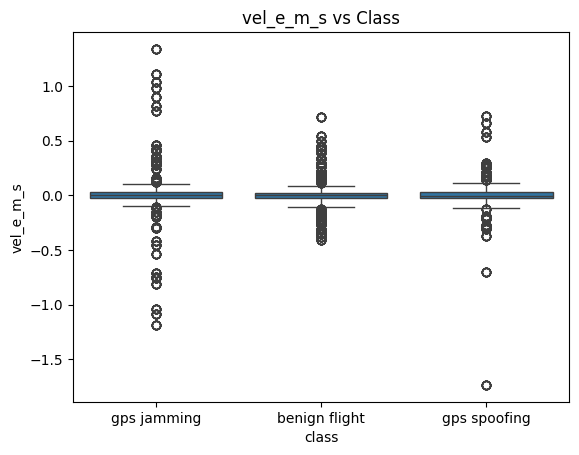

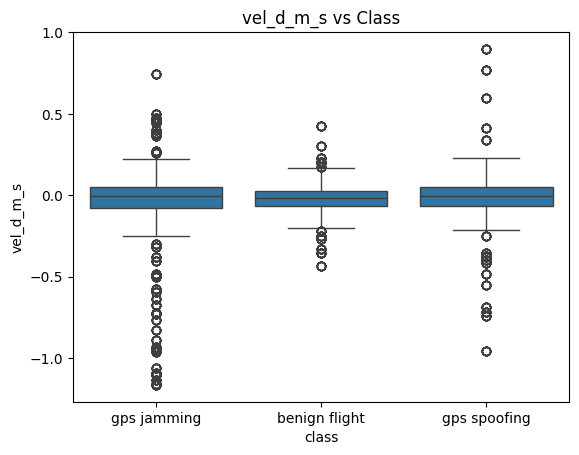

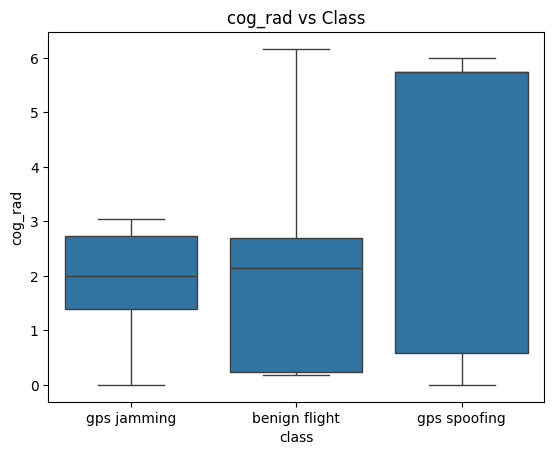

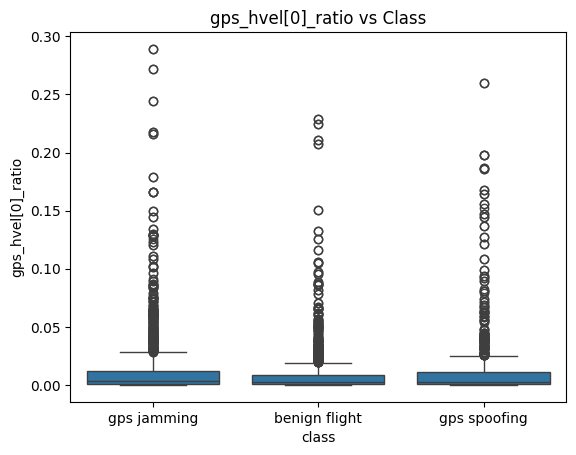

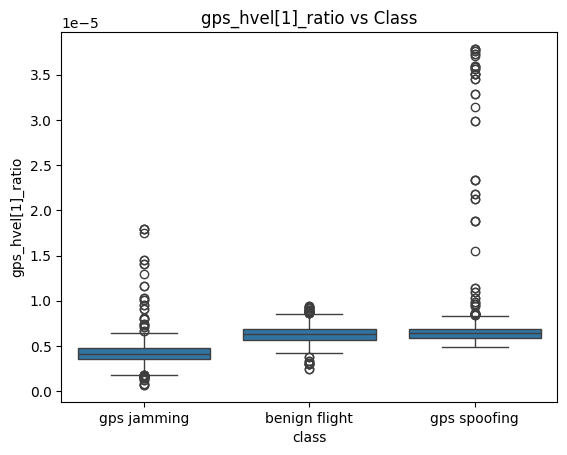

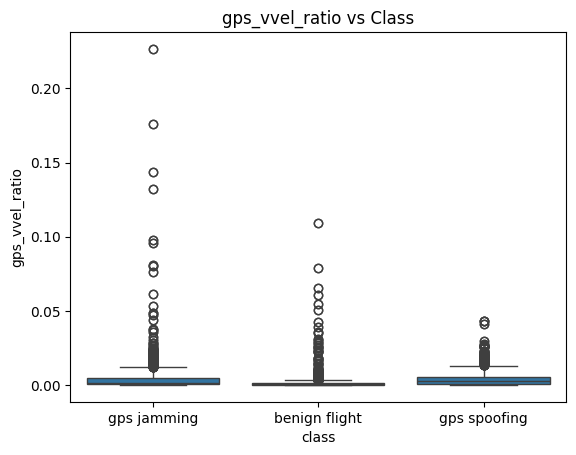

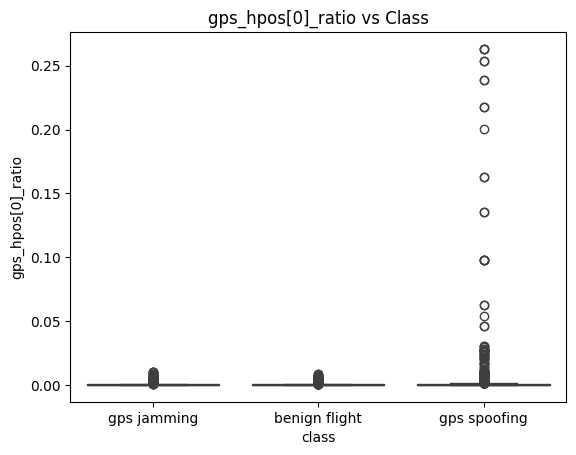

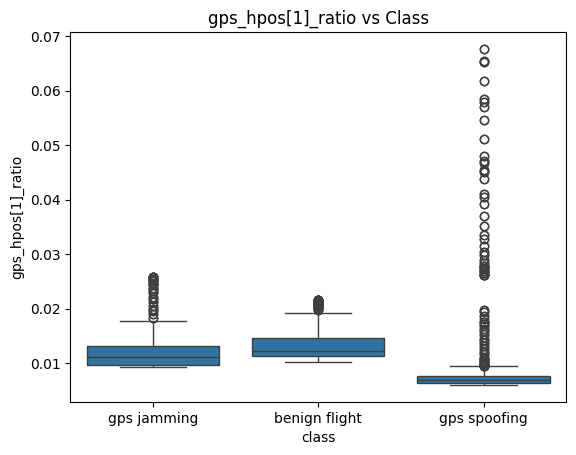

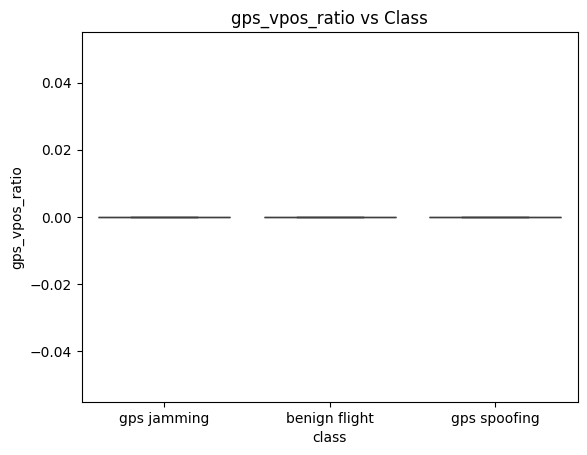

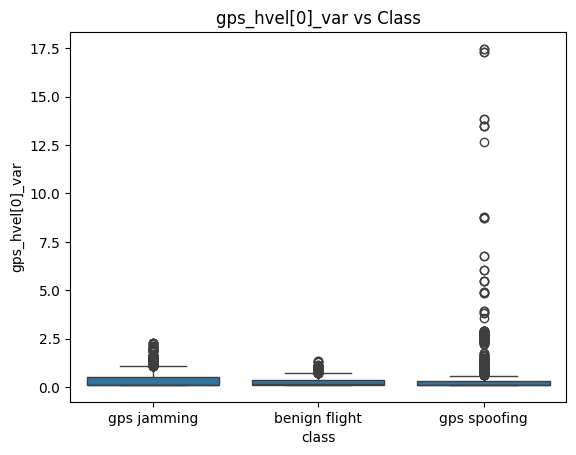

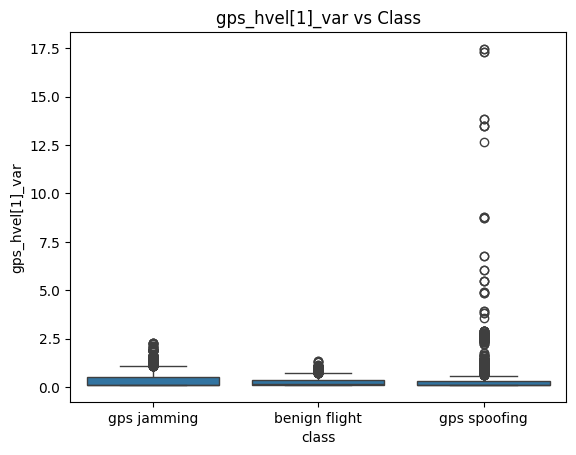

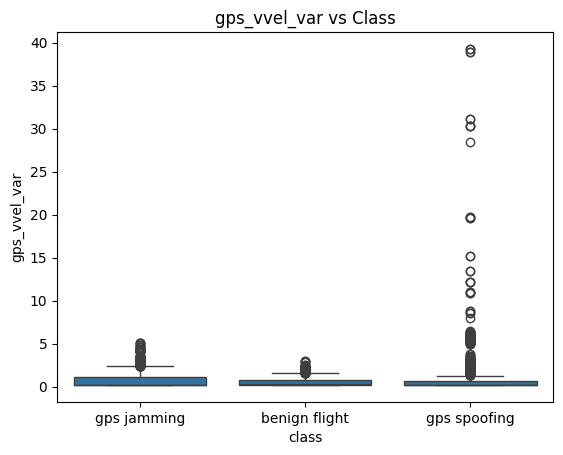

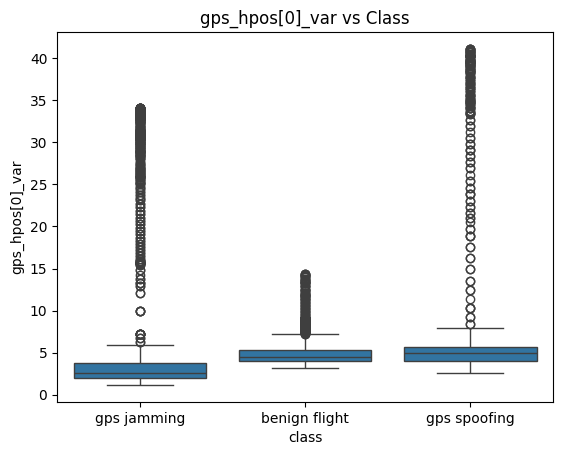

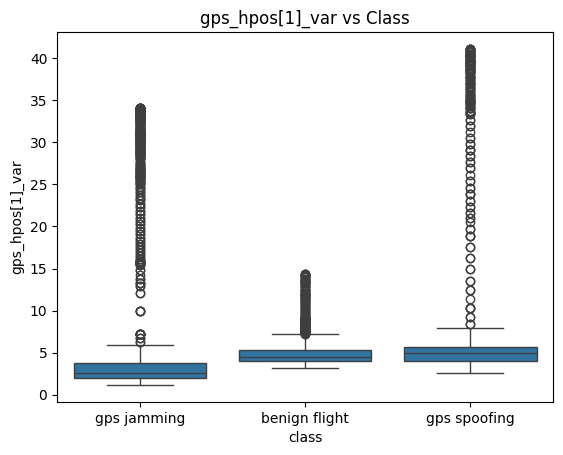

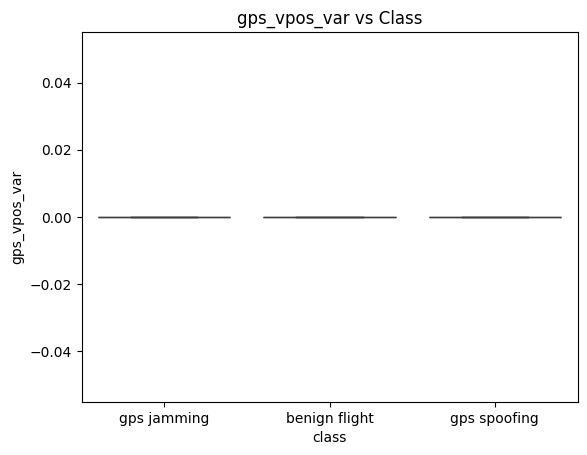

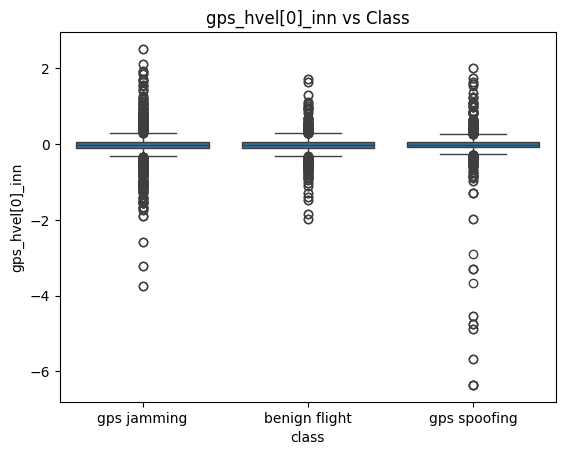

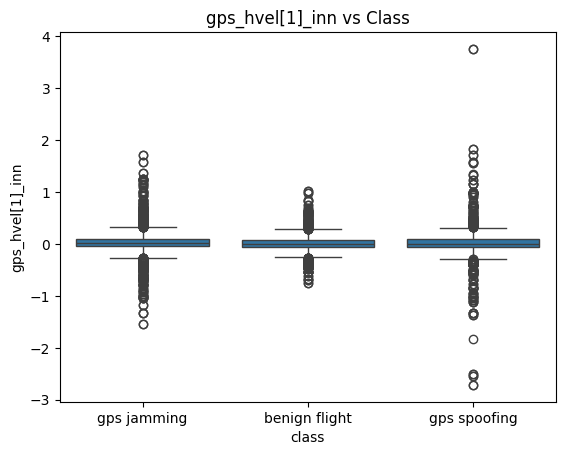

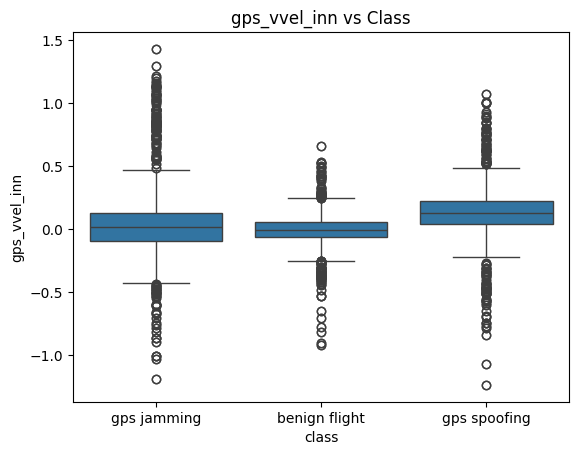

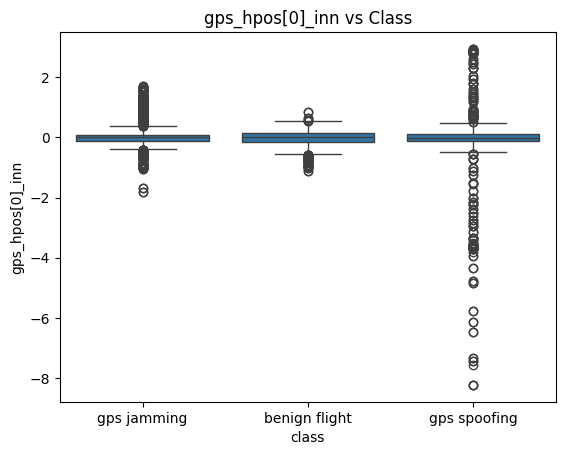

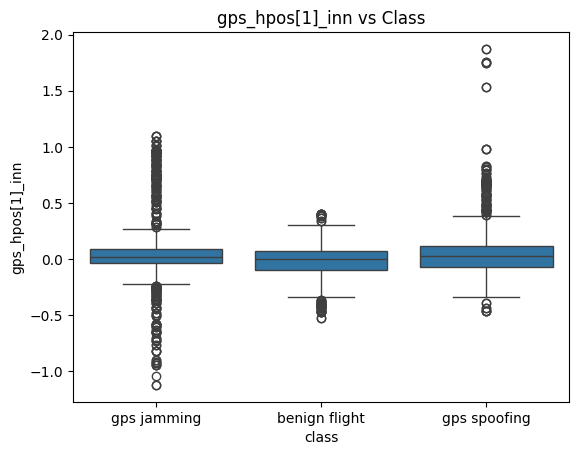

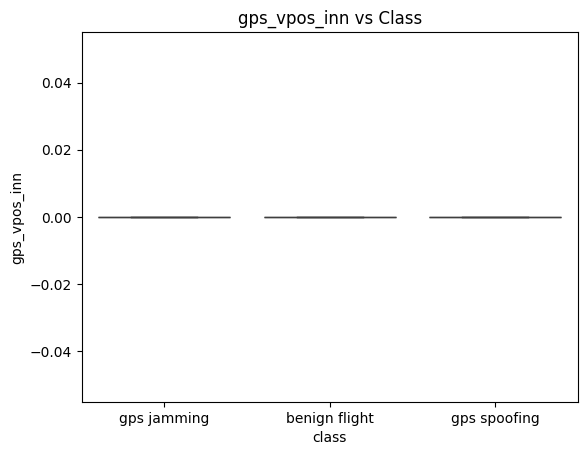

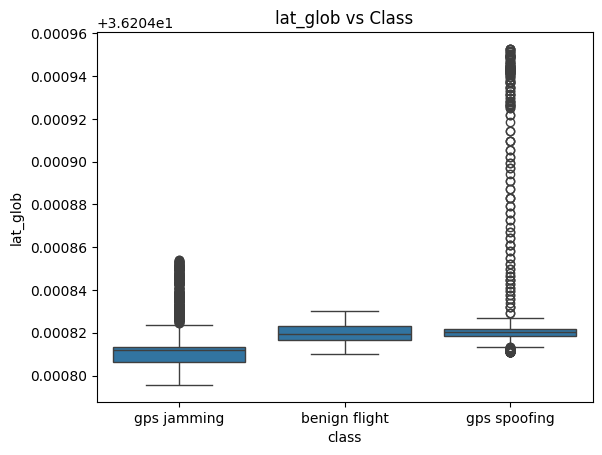

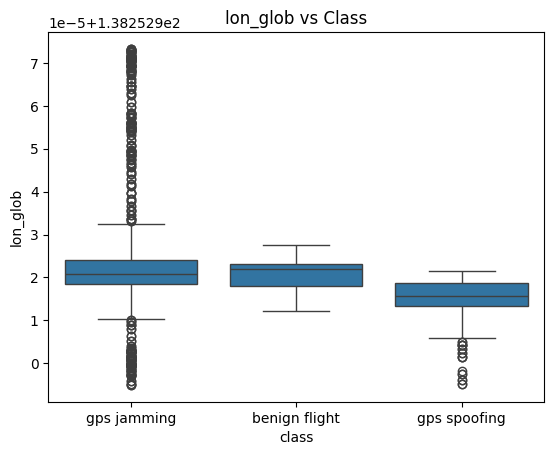

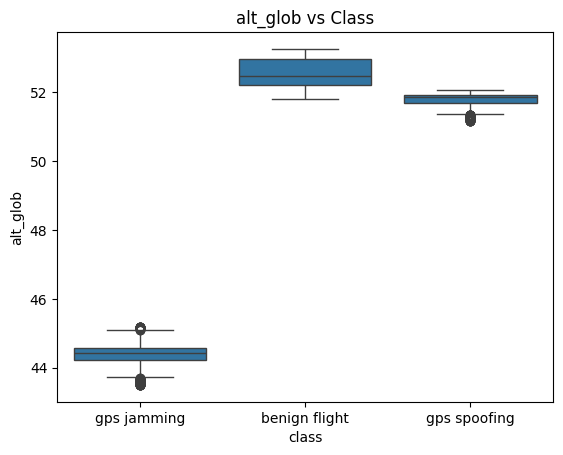

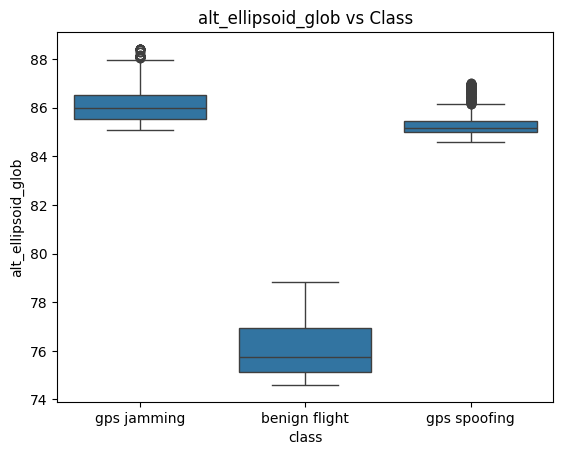

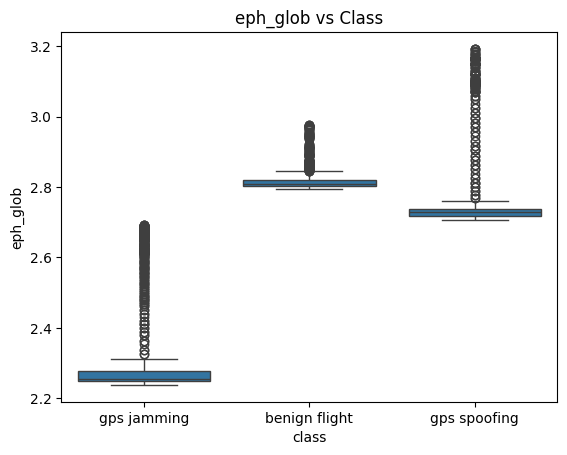

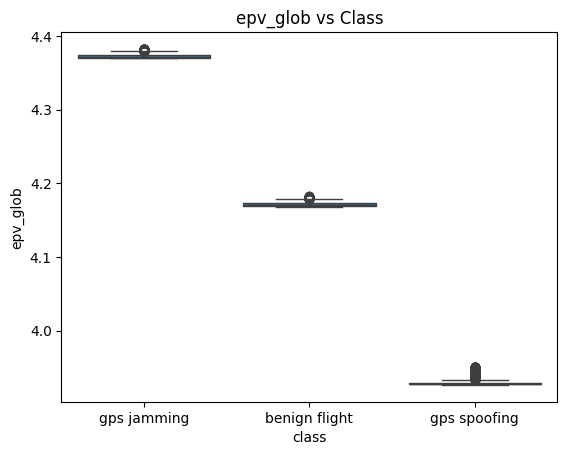

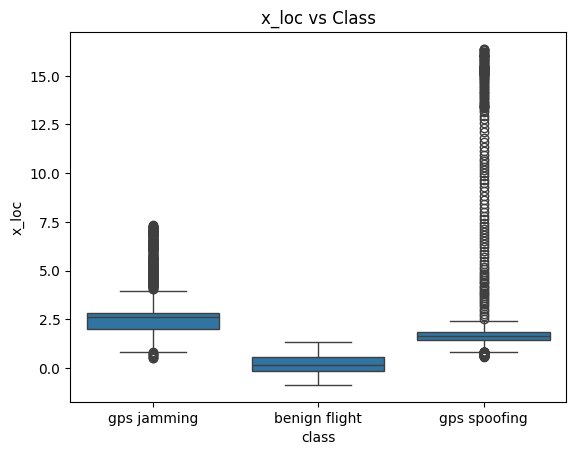

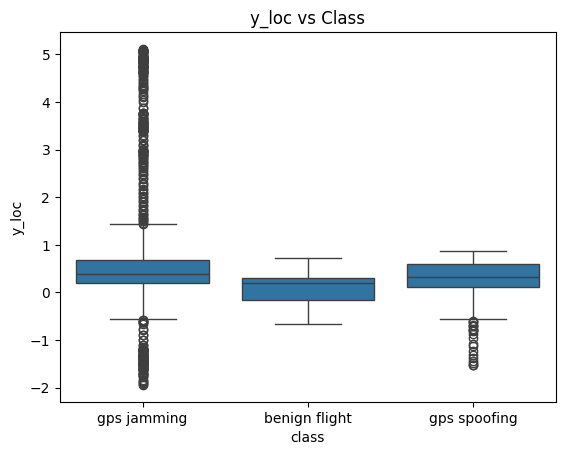

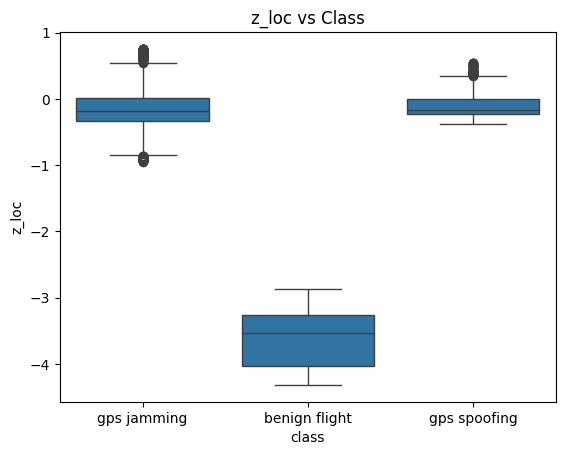

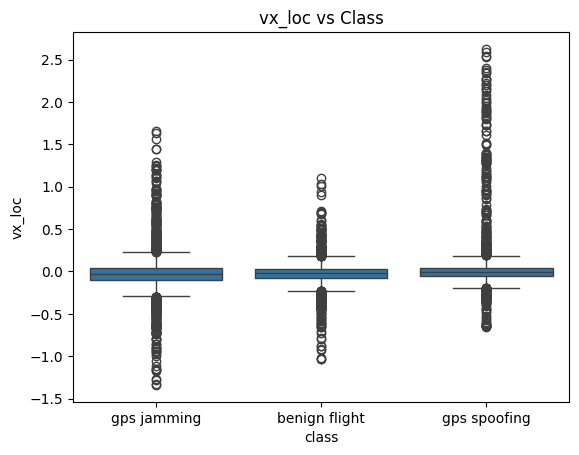

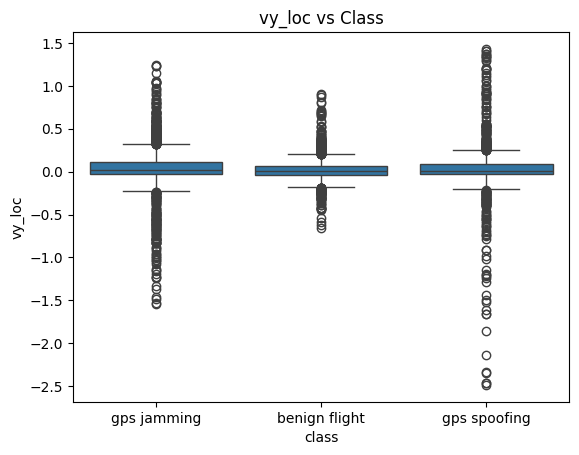

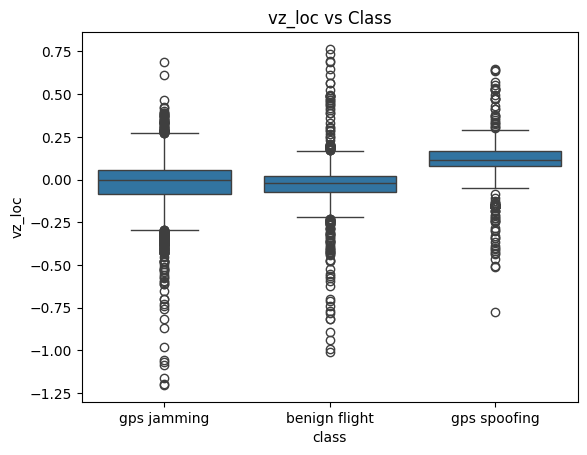

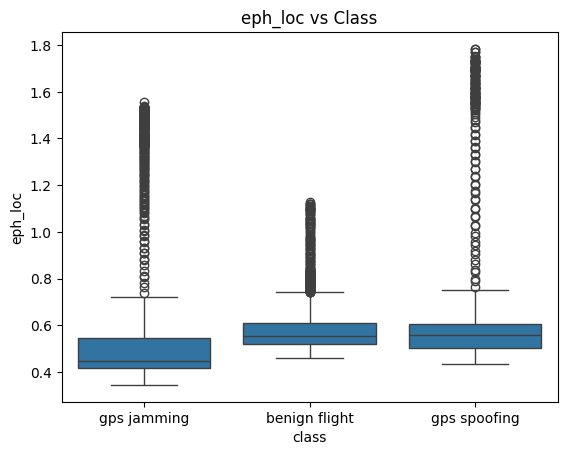

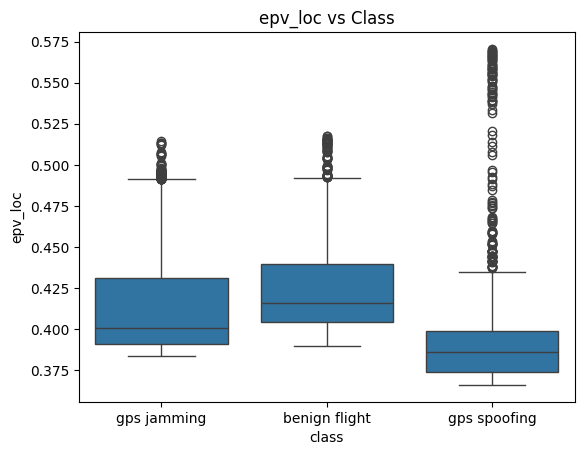

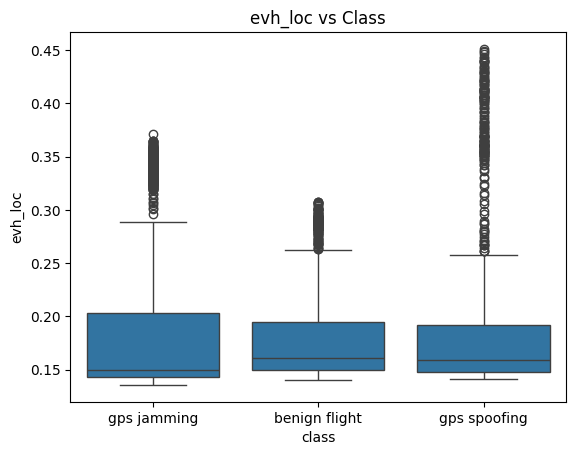

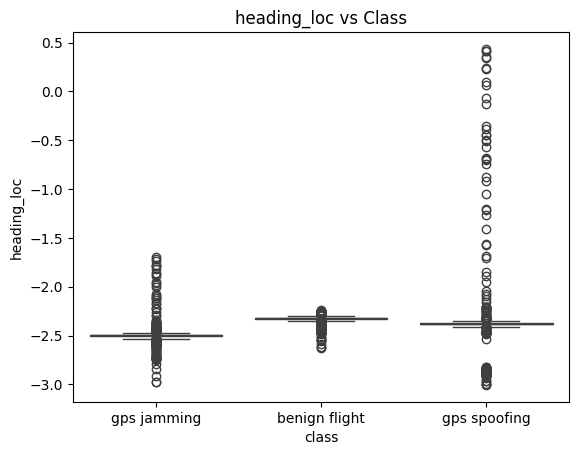

In [114]:
# We visualize how each numerical feature differs across classes.

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

for feature in numeric_features:
    sns.boxplot(x='class', y=feature, data=df)
    plt.title(f"{feature} vs Class")
    plt.show()

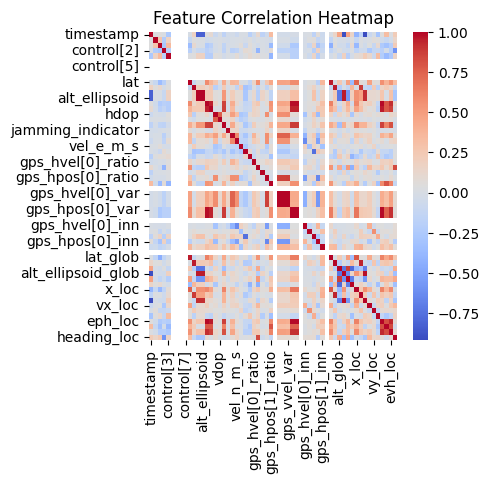

In [115]:
# We analyze correlations between numerical features.

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(4, 4))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

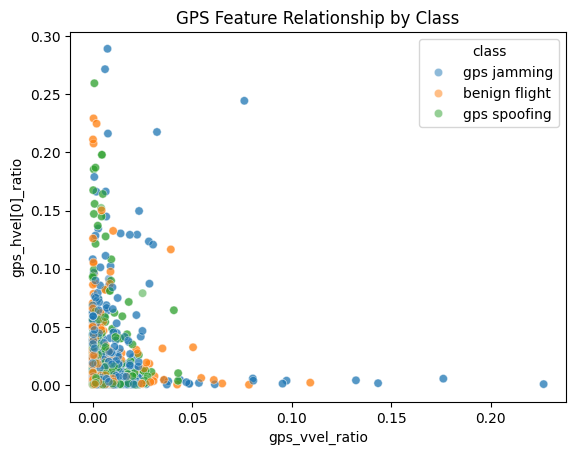

In [116]:
# We visualize the relationship between two correlated features.

sns.scatterplot(
    x='gps_vvel_ratio',
    y='gps_hvel[0]_ratio',
    hue='class',
    data=df,
    alpha=0.5
)

plt.title("GPS Feature Relationship by Class")
plt.show()

In [117]:
# We create a temporary numeric version of the target variable
# for correlation-based feature selection.

df_temp = df.copy()

df_temp['class_encoded'] = df_temp['class'].astype('category').cat.codes

In [118]:
numeric_df = df_temp.select_dtypes(include=['int64', 'float64'])

# We explicitly add the encoded target variable
numeric_df['class_encoded'] = df_temp['class_encoded']

In [119]:
corr_with_target = (
    numeric_df.corr()['class_encoded']
    .abs()
    .sort_values(ascending=False)
)

top_features = corr_with_target.drop('class_encoded').head(5).index
top_features

Index(['timestamp', 'z_loc', 'alt_ellipsoid_glob', 'alt', 'alt_ellipsoid'], dtype='object')

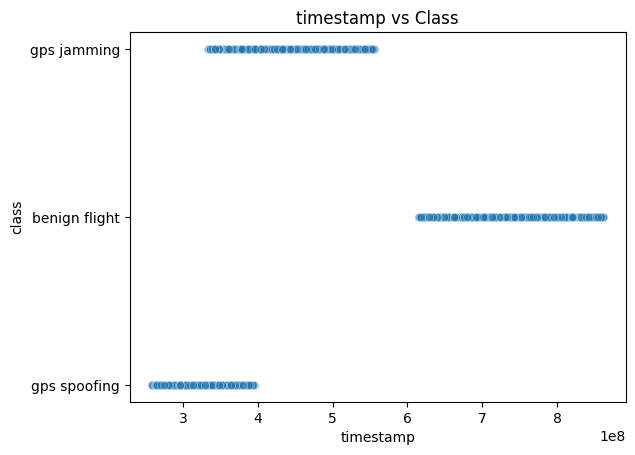

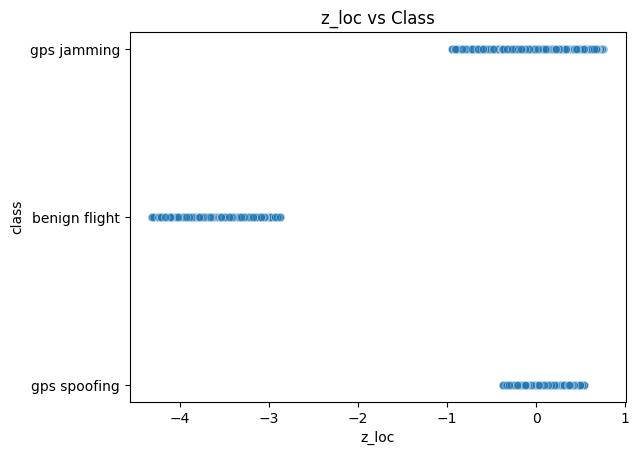

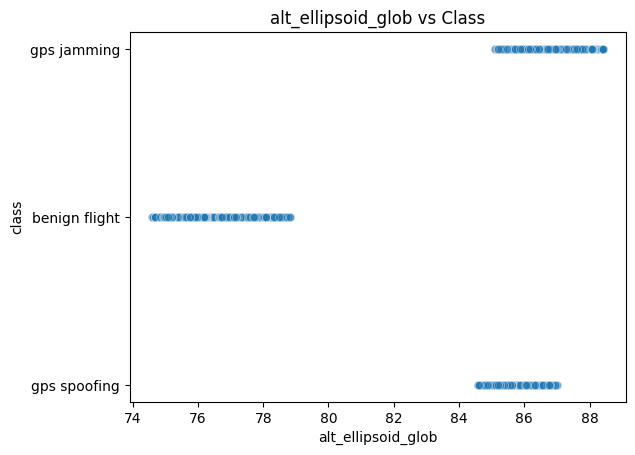

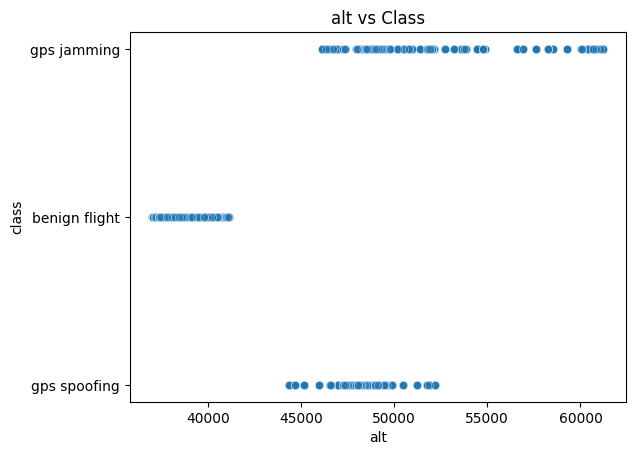

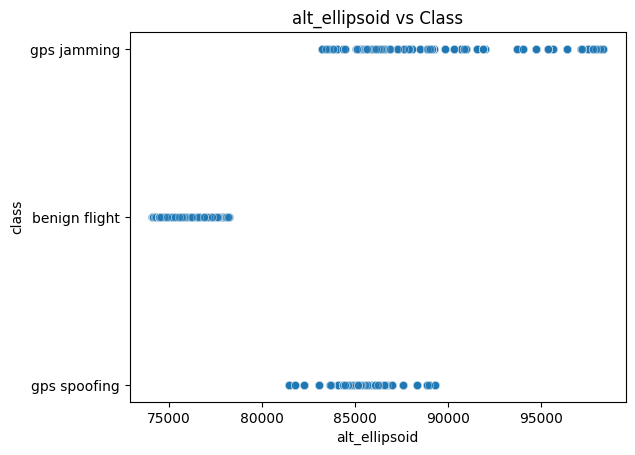

In [120]:
# We generate scatter plots for the most relevant features.

for feature in top_features:
    sns.scatterplot(x=feature, y='class', data=df, alpha=0.5)
    plt.title(f"{feature} vs Class")
    plt.show()

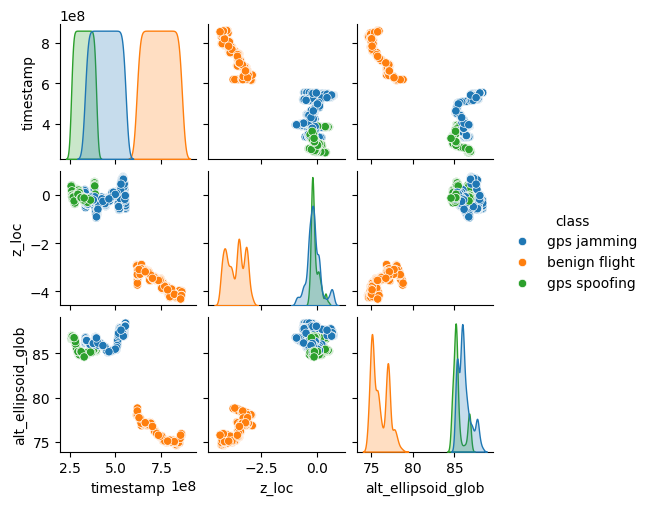

In [121]:
# We visualize pairwise relationships for a small subset of features.
selected_features = list(top_features[:3]) + ['class']
sns.pairplot(
    df[selected_features],
    hue='class',
    height=1.7,
    aspect=1.0
)

plt.show()

In [122]:
# We summarize the EDA findings before moving to modeling.

print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")
print("Target classes:", df['class'].unique())

Number of samples: 6046
Number of features: 58
Target classes: ['gps jamming' 'benign flight' 'gps spoofing']
